In [13]:
import pandas as pd
import psycopg2
import matplotlib.pyplot as plt
from chronos import ChronosPipeline
import torch
import warnings
warnings.filterwarnings('ignore')

# 1. Database Connection
print("Connecting to database...")
conn = psycopg2.connect(
    dbname="tsdb_transaction", user="vt_user_readonly",
    password="8lthoYeq5xarlwr3", host="timescale-replica.engr.harbingerplatform.com", port="5432"
)

# 2. Configuration
TARGET_FAULT = 'ABS_Fault' # You can change this to any fault!
CONTEXT_HOURS = 132 # 5.5 Days (8,192 minutes to max out Chronos context window)

print(f"Searching database for the most recent '{TARGET_FAULT}'...")

# 3. Step One: Find the Truck Automatically
find_fault_sql = f"""
    SELECT 
        deviceid AS truck_id,
        CAST(DATE_TRUNC('minute', time) AS TIMESTAMP) AS fault_time
    FROM fault_event 
    WHERE faultname = '{TARGET_FAULT}' 
    ORDER BY time DESC 
    LIMIT 1;
"""
fault_df = pd.read_sql_query(find_fault_sql, conn)

if fault_df.empty:
    raise ValueError(f"Could not find any '{TARGET_FAULT}' events in the database.")

target_truck = fault_df.iloc[0]['truck_id']
fault_time = fault_df.iloc[0]['fault_time']
print(f"-> Found Truck: {target_truck}")
print(f"-> Fault Time: {fault_time}")
print(f"Extracting {CONTEXT_HOURS} hours of deep telemetry context...")

# 4. Step Two: Dynamic SQL Generation for Denis's Signals
signals = [
    'RWAA_Steer_Sys_State', 'RWAB_Steer_Sys_State', 'RWAA_Steer_Sys_Fault', 'RWAB_Steer_Sys_Fault',
    'EBFM_BoostFail_Ind', 'EBRM_BoostFail_Ind', 'EBFM_ABS_Ind', 'EBFM_TCS_Ind', 'EBFM_ESC_Ind',
    'EBFM_FLuid_Stat', 'EBFM_EPB_Status', 'EBFM_BrakeSys_Stat', 'EBRM_BrakeSys_Stat',
    'IMU_Accel_Sensor_Status', 'IMU_Gyro_Sensor_Status', 
    'VCU_AccelControl_Est', 'VCU_Brake_Pedal_Pos', 'Steering_Wheel_Angle'
]

# Tell Python to automatically build the 90 columns (min, max, avg, first, last)
select_clauses = []
for sig in signals:
    select_clauses.append(f"MAX(CASE WHEN signal = '{sig}' THEN min_value END) AS {sig}_min")
    select_clauses.append(f"MAX(CASE WHEN signal = '{sig}' THEN max_value END) AS {sig}_max")
    select_clauses.append(f"MAX(CASE WHEN signal = '{sig}' THEN avg_value END) AS {sig}_avg")
    select_clauses.append(f"MAX(CASE WHEN signal = '{sig}' THEN first_value END) AS {sig}_first")
    select_clauses.append(f"MAX(CASE WHEN signal = '{sig}' THEN last_value END) AS {sig}_last")

formatted_signals = "', '".join(signals)
dynamic_select_string = ",\n        ".join(select_clauses)

extraction_sql = f"""
    WITH Filtered_Telemetry AS (
        SELECT bucket_1min, signal, min_value, max_value, avg_value, first_value, last_value
        FROM normalized_signal_1min
        WHERE deviceid = '{target_truck}'
            AND bucket_1min >= (CAST('{fault_time}' AS TIMESTAMP) - INTERVAL '{CONTEXT_HOURS} HOURS')
            AND bucket_1min <= CAST('{fault_time}' AS TIMESTAMP)
            AND signal IN ('{formatted_signals}')
    )
    SELECT 
        bucket_1min AS timestamp,
        {dynamic_select_string},
        MAX(CASE WHEN bucket_1min = CAST('{fault_time}' AS TIMESTAMP) THEN 1.0 ELSE 0.0 END) AS target_fault
    FROM Filtered_Telemetry
    GROUP BY bucket_1min
    ORDER BY bucket_1min ASC;
"""

df = pd.read_sql_query(extraction_sql, conn)
conn.close()

# Make columns lowercase to prevent Pandas naming errors later
df.columns = df.columns.str.lower()
print(f"Extraction complete: Created a massive matrix of {len(df)} rows and {len(df.columns)} columns.")

Connecting to database...
Searching database for the most recent 'ABS_Fault'...
-> Found Truck: 28e06c8e-f2d5-40e7-aa57-7e2879ecadab
-> Fault Time: 2026-04-01 18:34:00
Extracting 132 hours of deep telemetry context...
Extraction complete: Created a massive matrix of 205 rows and 92 columns.


In [16]:
print("Cleaning data and enforcing the 1-minute temporal grid...")
df['timestamp'] = pd.to_datetime(df['timestamp'])

# Resample to 1-minute grid and forward-fill missing sensor broadcasts
df = df.set_index('timestamp').resample('1min').ffill().reset_index()

# Fill any remaining absolute blanks with 0
df.fillna(0.0, inplace=True)
df['truck_id'] = target_truck

display(df.tail())

Cleaning data and enforcing the 1-minute temporal grid...


,timestamp,rwaa_steer_sys_state_min,rwaa_steer_sys_state_max,rwaa_steer_sys_state_avg,rwaa_steer_sys_state_first,rwaa_steer_sys_state_last,rwab_steer_sys_state_min,rwab_steer_sys_state_max,rwab_steer_sys_state_avg,rwab_steer_sys_state_first,...,vcu_brake_pedal_pos_avg,vcu_brake_pedal_pos_first,vcu_brake_pedal_pos_last,steering_wheel_angle_min,steering_wheel_angle_max,steering_wheel_angle_avg,steering_wheel_angle_first,steering_wheel_angle_last,target_fault,truck_id
334,2026-04-01 18:30:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,28e06c8e-f2d5-40e7-aa57-7e2879ecadab
335,2026-04-01 18:31:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,28e06c8e-f2d5-40e7-aa57-7e2879ecadab
336,2026-04-01 18:32:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,28e06c8e-f2d5-40e7-aa57-7e2879ecadab
337,2026-04-01 18:33:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,28e06c8e-f2d5-40e7-aa57-7e2879ecadab
338,2026-04-01 18:34:00,3.0,3.0,3.0,3.0,3.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,28e06c8e-f2d5-40e7-aa57-7e2879ecadab


In [23]:
# We are forecasting one of the actual system indicators, using the max value
ACTIVE_TARGET = 'RWAA_Steer_Sys_Fault'
PREDICTION_MINUTES = 120 

print(f"Loading Chronos-2 to forecast: {ACTIVE_TARGET}")
cutoff_time = df['timestamp'].max() - pd.Timedelta(minutes=PREDICTION_MINUTES)

# Split the 5.5 days into Context (Past) and Future (Hidden)
context_df = df[df['timestamp'] <= cutoff_time]
truth_df = df[df['timestamp'] > cutoff_time]

pipeline = ChronosPipeline.from_pretrained(
    "amazon/chronos-t5-small", device_map="auto", torch_dtype=torch.bfloat16,
)

# Run Inference
pred_df = pipeline.predict_df(
    context_df,
    prediction_length=PREDICTION_MINUTES,             
    quantile_levels=[0.1, 0.5, 0.9],   
    id_column="truck_id", timestamp_column="timestamp",
    target=ACTIVE_TARGET 
)
print("Inference complete!")

Loading Chronos-2 to forecast: ABS_Fault


ValueError: df does not contain all expected columns. Missing columns: ['ABS_Fault']

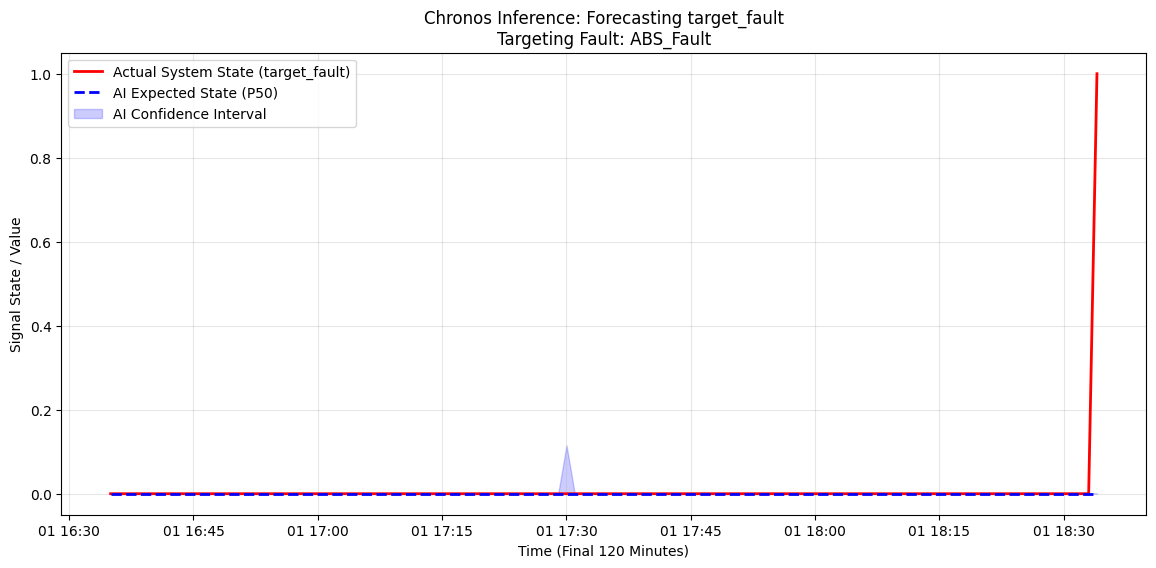

In [20]:
plt.figure(figsize=(14, 6))

# Plot actual reality (Red)
plt.plot(truth_df['timestamp'], truth_df[ACTIVE_TARGET], 
         label=f'Actual System State ({ACTIVE_TARGET})', color='red', linewidth=2)

# Plot AI Forecast (Blue)
plt.plot(pred_df['timestamp'], pred_df['0.5'], 
         label='AI Expected State (P50)', color='blue', linewidth=2, linestyle='--')

plt.fill_between(pred_df['timestamp'], pred_df['0.1'], pred_df['0.9'], 
                 color='blue', alpha=0.2, label='AI Confidence Interval')

plt.title(f"Chronos Inference: Forecasting {ACTIVE_TARGET}\nTargeting Fault: {TARGET_FAULT}")
plt.xlabel("Time (Final 120 Minutes)")
plt.ylabel("Signal State / Value")
plt.legend(loc="upper left")
plt.grid(True, alpha=0.3)
plt.show()